### Clustering for recommendation

In [55]:
import pandas as pd

# grouping the borrowings dataset by the book title

borrowings = pd.read_csv("../../../data/processed/library_borrowings.csv")

borrowings_agg = (borrowings.groupby("Title").agg(
        borrow_count=("Reader_num", "count"),
        avg_duration=("borrowing_duration", "mean"),
        category=("category", lambda x: x.mode()[0])
    ).reset_index()
)

print(borrowings_agg.shape)

borrowings_agg.head()

(132, 4)


,Title,borrow_count,avg_duration,category
0,400 EXERCICES CORRIGÉS D'ALGÈBRE AVEC RAPPELS ...,1,30.0,0
1,A FIRST COURSE IN PROBABILITY,2,15.0,2
2,ADVANCED CYBERSECURITY TECHNOLOGIES,2,18.5,3
3,ADVANCED DATA STRUCTURES: THEORY AND APPLICATIONS,1,15.0,1
4,AGILE STRATEGY MANAGEMENT : TECHNIQUES FOR CON...,2,15.0,1


In [56]:
# loading the inventory dataset and merging it with the borrowings_agg dataset

inventory = pd.read_csv("../../../data/processed/library_inventory.csv")

inventory_counts = (
    inventory
    .groupby("Title")
    .size()
    .reset_index(name="copy_count_inventory")
)

inventory_counts.head()

,Title,copy_count_inventory
0,"100 FICHES POUR BIEN DÉMARRER EN PRÉPA, 2021-2...",1
1,400 EXERCICES CORRIGÉS D'ALGÈBRE AVEC RAPPELS ...,1
2,50 [CINQUANTE]CLÉS POUR COMPRENDRE LA PHYSIQUE,2
3,8 ANS DE PROBLÈMES CORRIGÉS DE MATHÉMATIQUES P...,2
4,A FIRST COURSE IN PROBABILITY,3


In [57]:
# merging the 2 datasets

book_df = pd.merge(
    borrowings_agg,
    inventory_counts,
    on="Title",
    how="left"
)

print("missing values summary: ")
print(book_df.isna().sum())

book_df.head(10)

missing values summary: 
Title                   0
borrow_count            0
avg_duration            0
category                0
copy_count_inventory    0
dtype: int64


,Title,borrow_count,avg_duration,category,copy_count_inventory
0,400 EXERCICES CORRIGÉS D'ALGÈBRE AVEC RAPPELS ...,1,30.000000,0,1
1,A FIRST COURSE IN PROBABILITY,2,15.000000,2,3
2,ADVANCED CYBERSECURITY TECHNOLOGIES,2,18.500000,3,3
3,ADVANCED DATA STRUCTURES: THEORY AND APPLICATIONS,1,15.000000,1,3
4,AGILE STRATEGY MANAGEMENT : TECHNIQUES FOR CON...,2,15.000000,1,3
5,ALGEBRE 1 : RAPPELS DE COURS ET EXERCICES AVEC...,55,16.345455,1,135
6,ALGORITHMIQUE : COURS ET EXERCICES CORRIGÉS,4,14.000000,1,53
7,ALGORITHMIQUE ET PROGRAMMATION EN JAVA : COURS...,1,15.000000,1,6
8,ALGORITHMIQUE ET STRUCTURES DE DONNÉES STATIQU...,3,15.000000,1,4
9,ALGORITHMIQUE MODERNE ANALYSE ET COMPLEXITÉ,2,15.000000,1,62


In [58]:
#========================================================================
#---------------------------Start Clustering-----------------------------
#========================================================================

X = book_df[["borrow_count", "avg_duration", "category", "copy_count_inventory"]]
X.head()

,borrow_count,avg_duration,category,copy_count_inventory
0,1,30.0,0,1
1,2,15.0,2,3
2,2,18.5,3,3
3,1,15.0,1,3
4,2,15.0,1,3


In [59]:
# scaling the dataset since thay are on high different scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

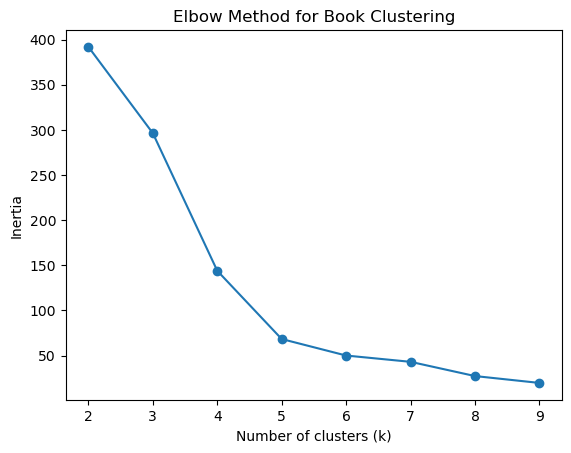

In [60]:
# deciding the number of clusters using elbow method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 10)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Book Clustering")
plt.show()

In [61]:
# we choose K = 5 as the number of clusters
# we apply clustering
K = 5
kmeans = KMeans(n_clusters=K, random_state=42)
book_df["cluster"] = kmeans.fit_predict(X_scaled)

c:\Users\LEGION\anaconda3\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [62]:
# evaluate the clustering

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, book_df["cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.562184308298205


In [63]:
# interpretation of clusters

cluster_summary = (book_df.groupby("cluster").agg(
    avg_borrow_count=("borrow_count", "mean"),
    avg_duration=("avg_duration", "mean"),
    avg_copies=("copy_count_inventory", "mean"),
    book_count=("Title", "count"))
)

print(cluster_summary)

         avg_borrow_count  avg_duration  avg_copies  book_count
cluster                                                        
0                1.000000    302.000000    1.500000           2
1                1.907407     15.665432    4.962963          54
2                1.525424     13.517326    4.186441          59
3               55.333333     15.774346  145.000000           3
4                4.285714     12.371882   94.071429          14


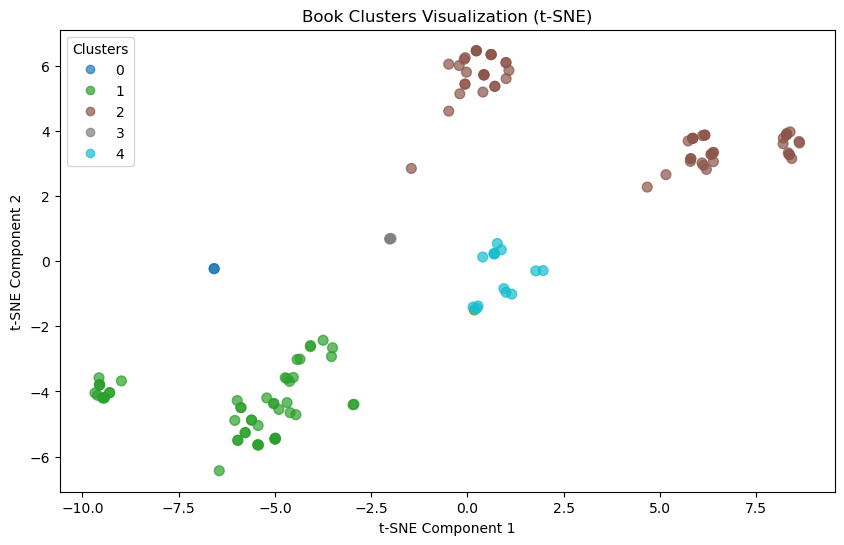

In [64]:
#========================================================================
#----------------------Visualization fo clusters-------------------------
#========================================================================


from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=book_df["cluster"],
    cmap='tab10',
    s=50,
    alpha=0.7
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Book Clusters Visualization (t-SNE)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()
